In [1]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")


In [2]:
controlx = [-1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1.2 1.5]
controly = [0. 0.3 0.5 0.7 1. 0.7 0.5 0.3 0.] .+ 1.
control = vcat(controlx, controly)
bezier(control, 0.5)
a = map( i-> bezier(control,i/100), 1:100)

100-element Vector{Vector{Float64}}:
 [-1.4754565911172077, 1.0237255956034095]
 [-1.449891075661824, 1.0469246619406027]
 [-1.4233968601362954, 1.0696301713110064]
 [-1.3960625755422715, 1.0918741469416648]
 [-1.3679722068749995, 1.1136872668281248]
 [-1.3392052207226874, 1.135098519387719]
 [-1.3098366910111432, 1.156134908150449]
 [-1.2799374229340164, 1.176821202772296]
 [-1.2495740751089526, 1.1971797337154995]
 [-1.2188092800000003, 1.2172302280000002]
 [-1.1877017626465682, 1.2369896834899121]
 [-1.156306457739264, 1.2564722792385743]
 [-1.1246746250829358, 1.2756893194754029]
 ⋮
 [1.187701762646568, 1.236989683489912]
 [1.2188092799999999, 1.217230228]
 [1.2495740751089521, 1.1971797337154992]
 [1.2799374229340161, 1.1768212027722957]
 [1.309836691011144, 1.1561349081504493]
 [1.3392052207226879, 1.1350985193877197]
 [1.367972206875, 1.113687266828125]
 [1.3960625755422718, 1.0918741469416653]
 [1.4233968601362958, 1.0696301713110064]
 [1.449891075661824, 1.046924661940603]
 [1

On définit un type appelé ray (struct) :

In [3]:
ray = Ray([-0.5, 0.], pi/2.)

Ray([-0.5, 0.0], 1.5707963267948966)

On peut utiuliser les générateurs pour éviter d'avoir à stocker un grand nombre de rayons

In [4]:
Nx = 10
Ntheta = 5
#angles = (-0.2 + i / Ntheta * 0.4 for i in 0:Ntheta)
angles = Iterators.map( i -> pi / 2 -0.2 + i / Ntheta * 0.4, 0:Ntheta)
#Il faut créer les couleurs ici et les associer aux bonnes directions de rayons.

Base.Generator{UnitRange{Int64}, var"#17#18"}(var"#17#18"(), 0:5)

Les rays sont sous forme de matrices dont les lignes correspondent à chaque position et les colonnes aux vitesses

In [5]:
source = (Ray([-0.5 +  i / Nx, 0. ], theta ) for i in 0:Nx, theta in angles )
length(source)
collect(source)

11×6 Matrix{Ray}:
 Ray([-0.5, 0.0], 1.3708)  …  Ray([-0.5, 0.0], 1.7708)
 Ray([-0.4, 0.0], 1.3708)     Ray([-0.4, 0.0], 1.7708)
 Ray([-0.3, 0.0], 1.3708)     Ray([-0.3, 0.0], 1.7708)
 Ray([-0.2, 0.0], 1.3708)     Ray([-0.2, 0.0], 1.7708)
 Ray([-0.1, 0.0], 1.3708)     Ray([-0.1, 0.0], 1.7708)
 Ray([0.0, 0.0], 1.3708)   …  Ray([0.0, 0.0], 1.7708)
 Ray([0.1, 0.0], 1.3708)      Ray([0.1, 0.0], 1.7708)
 Ray([0.2, 0.0], 1.3708)      Ray([0.2, 0.0], 1.7708)
 Ray([0.3, 0.0], 1.3708)      Ray([0.3, 0.0], 1.7708)
 Ray([0.4, 0.0], 1.3708)      Ray([0.4, 0.0], 1.7708)
 Ray([0.5, 0.0], 1.3708)   …  Ray([0.5, 0.0], 1.7708)

On utilise map dans ce qui suit mais la syntaxe précédente fonctionne aussi

In [6]:
refrays = Iterators.map( ray-> projectionmirror(control, ray), source);
Xf = Iterators.map( ray -> projectionplanfocal(ray), refrays);
typeof(refrays)
ray = Ray([0.1,0.], pi / 2.)
println(billiard(control,ray))

Ray([0.10000000000000019, 1.702837420862658], -1.7682008805466198)


La méthode plot est étendu aux rayons

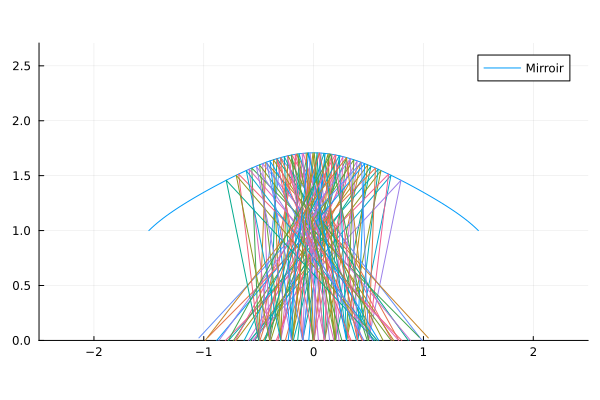

In [7]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirroir")
for ray in source
    plot!(ray)
end
display(plt)
#plot!(Ray([0.1,0.], pi / 2.))
#plot!(Ray([0.,0.], pi / 1.9))
#display(plt)

In [8]:
if isempty(filename) == false
    savefig(plt,filename)
end

In [13]:
#Vérification courbure
veps = (10.0)^(-10)
dic1 = geometricquantities(control, 0.5 + veps)
dic2 = geometricquantities(control, 0.5 - veps )
dic3 = geometricquantities(control, 0.5 )
(dic1["normal"] - dic2["normal"] ) ./ (2 * veps) 

2-element Vector{Float64}:
 2.8370037596680815
 0.0

Attention on parcourt la courbe de gauche à droite. Pour un cercle dont la paramétrisation se fait dans le sens anti trigo, la courbure devient négative

In [14]:
dic3["curvature"] 

-0.9998253410700769

In [15]:
dic3["normtangent"]

2.8374999999999995

In [16]:
dic3["normal"]

2-element Vector{Float64}:
 0.0
 1.0

In [18]:
dic3["utangent"]

2-element Vector{Float64}:
 1.0
 0.0